In [2]:
!pip install numpy
!pip install pandas
!pip install openpyxl
!pip install matplotlib

  Using cached numpy-2.5.1-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
Using cached numpy-2.5.1-cp314-cp314-win_amd64.whl (12.6 MB)



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel('First Dataset.xlsx')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         61 non-null     int64  
 1   first_name          61 non-null     str    
 2   gender              61 non-null     str    
 3   age                 60 non-null     float64
 4   city                61 non-null     str    
 5   province            61 non-null     str    
 6   signup_date         61 non-null     str    
 7   membership_tier     61 non-null     str    
 8   purchase_count      61 non-null     int64  
 9   avg_order_value     61 non-null     float64
 10  total_spending      60 non-null     float64
 11  last_purchase_days  61 non-null     int64  
 12  payment_method      61 non-null     str    
 13  device              61 non-null     str    
 14  discount_used       61 non-null     str    
 15  returned_items      61 non-null     int64  
 16  satisfaction_score  6

In [5]:
df.describe(include='all')

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
count,61.000000,61,61,60.000000,61,61,61,61,61.000000,61.000000,60.000000,61.000000,61,61,61,61.000000,61.00000
unique,NaN,12,2,NaN,8,8,58,4,NaN,NaN,NaN,NaN,3,3,2,NaN,NaN
top,NaN,Reza,F,NaN,Tabriz,East Azerbaijan,2021-11-08,Gold,NaN,NaN,NaN,NaN,Online Wallet,Android,No,NaN,NaN
freq,NaN,8,35,NaN,13,13,2,19,NaN,NaN,NaN,NaN,23,23,35,NaN,NaN
mean,1030.229508,NaN,NaN,45.200000,NaN,NaN,NaN,NaN,17.606557,211.435738,3749.667333,196.934426,NaN,NaN,NaN,4.196721,3.00000
std,17.446483,NaN,NaN,19.167239,NaN,NaN,NaN,NaN,10.214824,130.113726,4262.248522,97.892436,NaN,NaN,NaN,2.663454,1.42595
min,1001.000000,NaN,NaN,19.000000,NaN,NaN,NaN,NaN,0.000000,27.630000,0.000000,3.000000,NaN,NaN,NaN,0.000000,1.00000
25%,1015.000000,NaN,NaN,31.750000,NaN,NaN,NaN,NaN,11.000000,108.190000,1167.035000,132.000000,NaN,NaN,NaN,2.000000,2.00000
50%,1030.000000,NaN,NaN,45.000000,NaN,NaN,NaN,NaN,17.000000,161.330000,2188.865000,201.000000,NaN,NaN,NaN,4.000000,3.00000
75%,1045.000000,NaN,NaN,58.000000,NaN,NaN,NaN,NaN,26.000000,323.320000,4692.150000,273.000000,NaN,NaN,NaN,7.000000,4.00000


In [6]:
df.describe(include=[np.number])

,customer_id,age,purchase_count,avg_order_value,total_spending,last_purchase_days,returned_items,satisfaction_score
count,61.000000,60.000000,61.000000,61.000000,60.000000,61.000000,61.000000,61.00000
mean,1030.229508,45.200000,17.606557,211.435738,3749.667333,196.934426,4.196721,3.00000
std,17.446483,19.167239,10.214824,130.113726,4262.248522,97.892436,2.663454,1.42595
min,1001.000000,19.000000,0.000000,27.630000,0.000000,3.000000,0.000000,1.00000
25%,1015.000000,31.750000,11.000000,108.190000,1167.035000,132.000000,2.000000,2.00000
50%,1030.000000,45.000000,17.000000,161.330000,2188.865000,201.000000,4.000000,3.00000
75%,1045.000000,58.000000,26.000000,323.320000,4692.150000,273.000000,7.000000,4.00000
max,1060.000000,145.000000,35.000000,449.810000,25000.000000,365.000000,8.000000,5.00000


In [7]:
df.describe(include='str')

,first_name,gender,city,province,signup_date,membership_tier,payment_method,device,discount_used
count,61,61,61,61,61,61,61,61,61
unique,12,2,8,8,58,4,3,3,2
top,Reza,F,Tabriz,East Azerbaijan,2021-11-08,Gold,Online Wallet,Android,No
freq,8,35,13,13,2,19,23,23,35


In [8]:
df.duplicated()

0     False
1     False
2     False
3     False
4     False
      ...  
56    False
57    False
58    False
59    False
60     True
Length: 61, dtype: bool

In [9]:
df.duplicated().sum()

np.int64(1)

In [10]:
df[df.duplicated()]

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
60,1014,Reza,M,35.0,Tabriz,East Azerbaijan,2022-08-26,VIP,31,108.19,3353.89,97,Card,Android,No,5,4


In [11]:
df_clean = df.drop_duplicates()

In [12]:
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].mean())

In [13]:
df_clean['total_spending'] = df_clean['total_spending'].fillna(df["purchase_count"] * df["avg_order_value"])

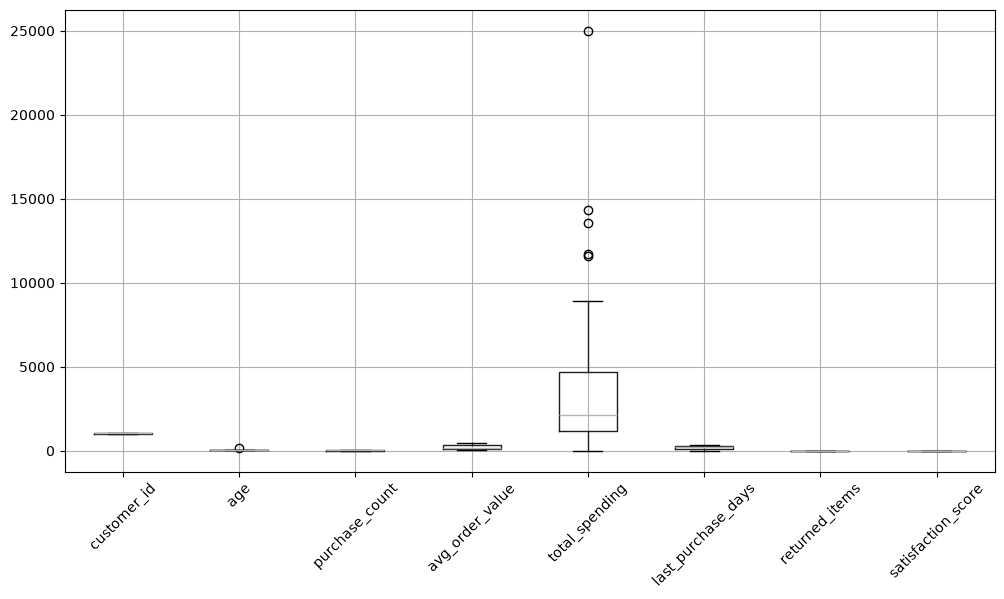

In [14]:
df_clean.select_dtypes(include=[np.number]).boxplot(figsize=(12, 6), rot=45)
plt.show()

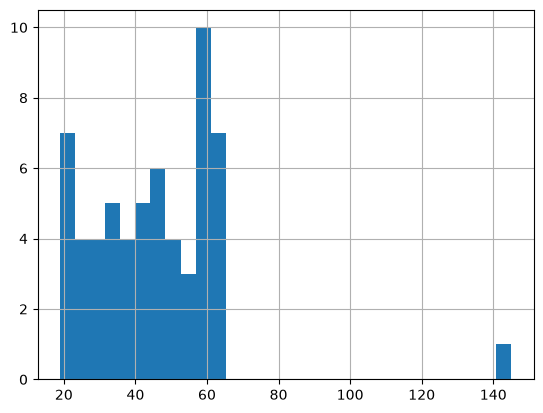

In [15]:
df['age'].hist(bins=30)
plt.show()

In [16]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

In [17]:
age_outlier, lower_age, upper_age = detect_outliers_iqr(df_clean, 'age')
print(age_outlier)
print("=============")
print(lower_age, upper_age)

   customer_id first_name gender    age   city province signup_date  \
9         1010      Arash      F  145.0  Karaj   Alborz  2022-06-25   

  membership_tier  purchase_count  avg_order_value  total_spending  \
9          Silver              19           381.13         7241.47   

   last_purchase_days payment_method   device discount_used  returned_items  \
9                 276  Online Wallet  Android            No               7   

   satisfaction_score  
9                   1  
-7.625 97.375


In [18]:
df_clean.loc[df_clean['age'] > upper_age, 'age'] = df_clean['age'].median()

In [19]:
df_clean['signup_date'] = pd.to_datetime(df_clean['signup_date'])

In [20]:
df_clean.describe()

,customer_id,age,signup_date,purchase_count,avg_order_value,total_spending,last_purchase_days,returned_items,satisfaction_score
count,60.000000,60.000000,60,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000
mean,1030.500000,43.709322,2023-02-03 14:00:00,17.383333,213.156500,3715.109833,198.600000,4.183333,2.983333
min,1001.000000,19.000000,2021-02-23 00:00:00,0.000000,27.630000,0.000000,3.000000,0.000000,1.000000
25%,1015.750000,31.750000,2021-12-06 12:00:00,10.750000,108.137500,1167.035000,134.250000,2.000000,2.000000
50%,1030.500000,45.093220,2022-08-15 00:00:00,17.000000,165.435000,2128.690000,203.000000,4.000000,3.000000
75%,1045.250000,58.000000,2024-06-14 12:00:00,24.500000,324.107500,4692.150000,273.750000,7.000000,4.000000
max,1060.000000,65.000000,2025-09-09 00:00:00,35.000000,449.810000,25000.000000,365.000000,8.000000,5.000000
std,17.464249,13.947980,NaN,10.149880,130.509923,4273.901437,97.843043,2.683861,1.431979


In [21]:
df_clean.to_excel('cleaned_dataset.xlsx', index=False)